# Series de tiempo

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import legend
from scipy.ndimage import label
import pickle
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
#from utils import *
import warnings
warnings.filterwarnings("ignore")

## Paso 1: Carga del conjunto de datos

Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

In [77]:
df = pd.read_csv('../data/raw/sales.csv')
df.head(10)

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
5,2022-09-08 17:10:08.079328,60.081865
6,2022-09-09 17:10:08.079328,68.466704
7,2022-09-10 17:10:08.079328,67.765106
8,2022-09-11 17:10:08.079328,70.512261
9,2022-09-12 17:10:08.079328,74.656453


In [78]:
df.shape

(366, 2)

In [79]:
df.dtypes

date      object
sales    float64
dtype: object

In [80]:
df.isna().sum()

date     0
sales    0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.nunique()

date     366
sales    366
dtype: int64

> Observaciones:
>
> - No tenemos valores nulos, ni datos duplicados.
> - La columna de fecha está en formato cadena (tipo object).

## Paso 2: Construye y analiza la serie temporal

> Construye la estructura de datos válida para la serie temporal, grafícala y, a continuación, analízala y responde a las siguientes preguntas:
>
> - ¿Cuál es el tensor de la serie temporal?
> - ¿Cuál es la tendencia?
> - ¿Es estacionaria?
> - ¿Existe variabilidad o presencia de ruido?

Visualizaremos la serie temporal para llevar a cabo un análisis visual de la misma:

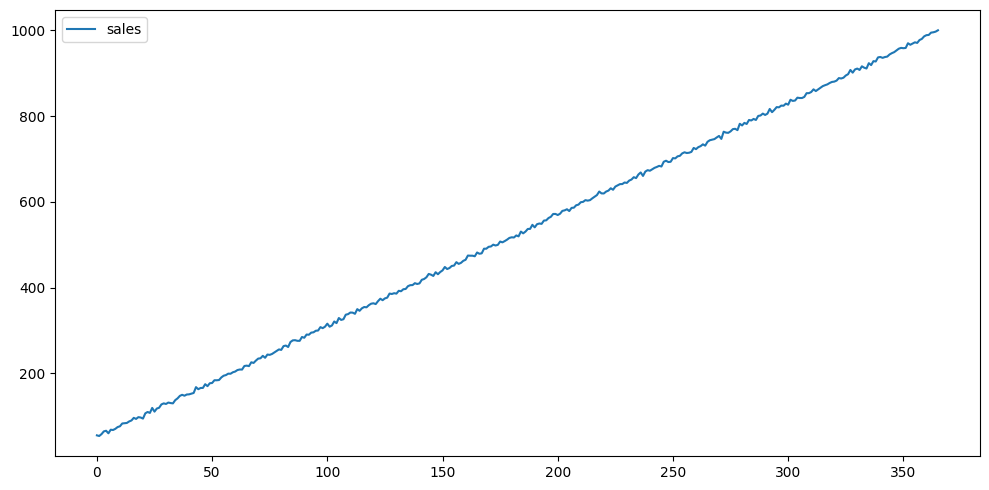

In [83]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=df)
plt.tight_layout()
plt.show()

### Limpieza de datos

Como nuestra columna `date` sigue siendo cadena (object), la convertimos a datetime.

In [84]:
df.dtypes

date      object
sales    float64
dtype: object

In [85]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
# We leave only the date in the index, removing the time
df.index = df.index.normalize()

In [86]:
ts = df['sales']
ts

date
2022-09-03      55.292157
2022-09-04      53.803211
2022-09-05      58.141693
2022-09-06      64.530899
2022-09-07      66.013633
                 ...     
2023-08-30     989.600354
2023-08-31     994.987326
2023-09-01     995.814415
2023-09-02     997.350214
2023-09-03    1000.482785
Freq: D, Name: sales, Length: 366, dtype: float64

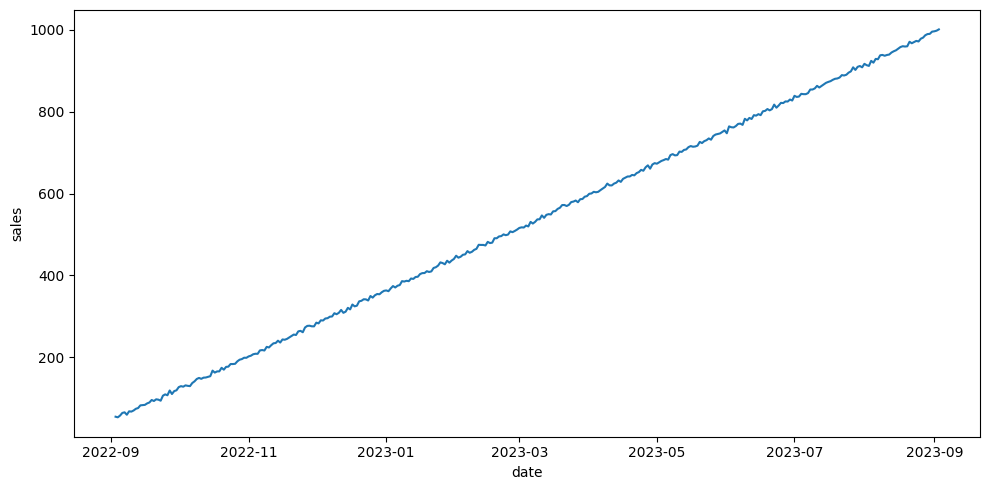

In [87]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts)
plt.tight_layout()
plt.show()

> ### Análisis:
> 
> - Tendencia: Se aprecia una tendencia ascendente, lo que indica que el número de ventas ha aumentado casda día a lo largo del tiempo. 
> - Estacionalidad: En nuestro caso no se observa estacionalidad en los datos.
> - Variabilidad: No se observan puntos de variabilidad en la serie temporal, porque la demanda casi siempre aumenta.
> - Puntos atípicos (Outliers): Estudiando la tendencia y la estacionalidad de la serie temporal, no se aprecian outliers en la serie temporal.
> - La línea presenta un crecimiento constante, por lo que no se observan puntos de inflexión, ya que la pendiente no varía a lo largo del tiempo.

#### Descomposición de la serie

La descomposición de una serie de tiempo puede ser muy útil para entender mejor los datos y tomar decisiones informadas al construir modelos de pronóstico. Como nuestro data set es diario, necesitamos el periodo según el tipo de estacionalidad, como no tenemos datos de varios años elegimos ciclo semanal (period=7).

In [88]:
decomposition = seasonal_decompose(ts, period=7)
decomposition

#### Análisis de la tendencia

La tendencia se refiere a la dirección general en la que se mueven los datos. Para acceder a su información recurrimos al componente trend del resultado decomposition.

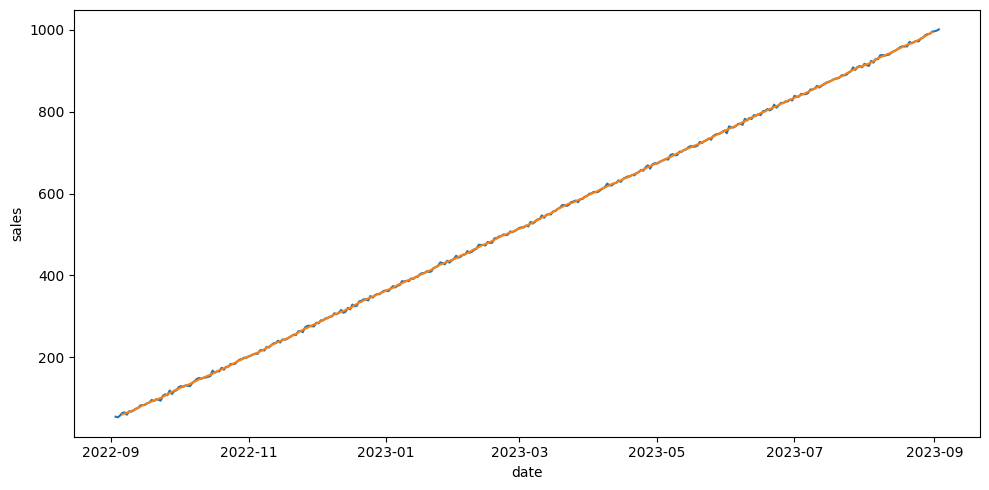

In [89]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts)
sns.lineplot(data=trend)

plt.tight_layout()
plt.show()

Se confirma lo observado: una clara tendencia positiva a lo largo de las semanas.  

#### Análisis de la estacionalidad

La estacionalidad se refiere a los patrones repetitivos en los datos. Para acceder a su información recurrimos al componente seasonal del resultado decomposition.

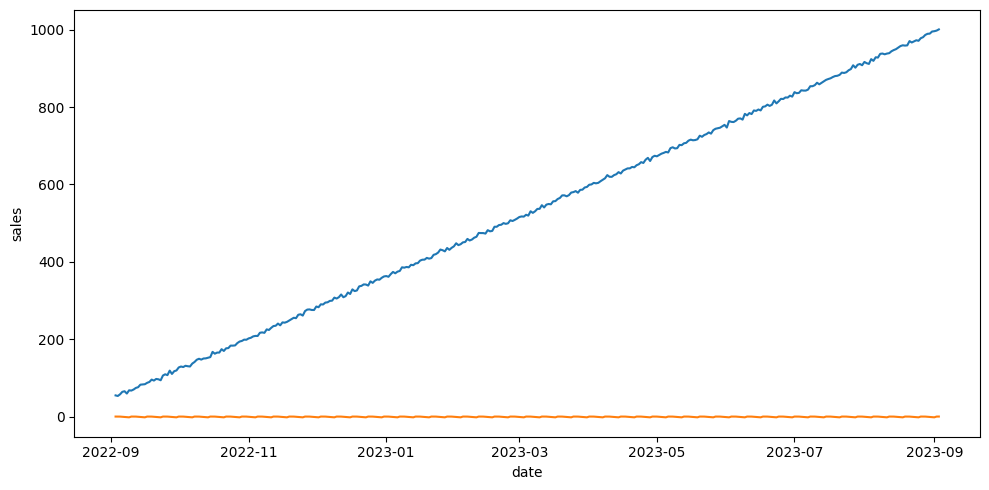

In [90]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts)
sns.lineplot(data=seasonal)
plt.tight_layout()
plt.show()

Para evaluar la estacionalidad de la serie temporal podemos aplicar la llamada Prueba de Dickey-Fuller (Dickey-Fuller test), que es un contraste de hipótesis en el que la hipótesis nula es que la serie es estacionaria, y la alternativa, que es no estacionaria:

In [91]:
def test_stationarity(timeseries):
    dftest = adfuller(timeseries, autolag = 'AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    return dfoutput

test_stationarity(ts)

Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

> Observaciones:
>
> El p-value es mayor a 0.05, esto significa que nuestra hipótesis nula no se rechaza. No hay suficiente evidencia estadística para apoyar la hipótesis alternativa.

#### Análisis de la variabilidad

La variabilidad implica el estudio de los residuos: que es cómo fluctúan los datos una vez se ha estudiado la tendencia y la estacionalidad. Para acceder a su información recurrimos al componente resid del resultado decomposition.

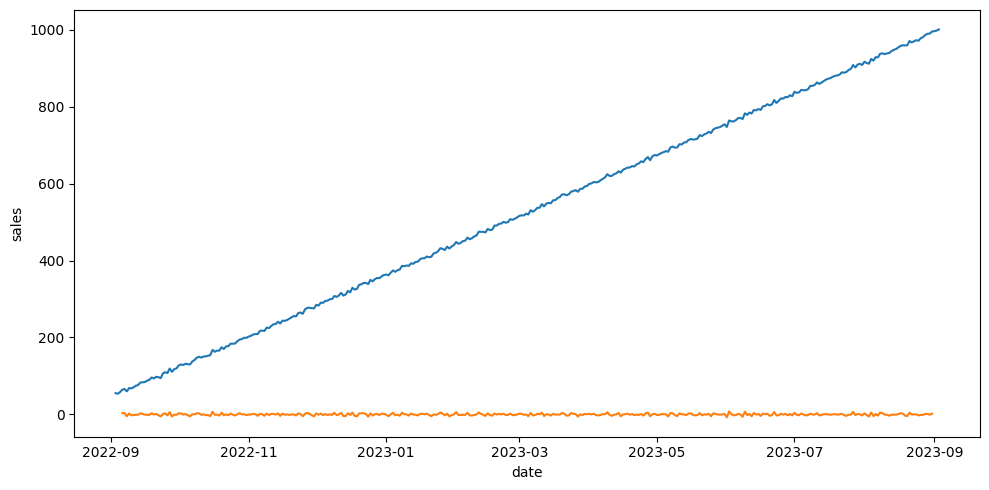

In [92]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts)
sns.lineplot(data=residual)
plt.tight_layout()
plt.show()

#### Análisis de la autocorrelación

La autocorrelación es la correlación de una serie de tiempo con una copia retrasada de sí misma. Este gráfico nos ayuda a ver si los valores en la serie de tiempo están correlacionados con los valores anteriores.

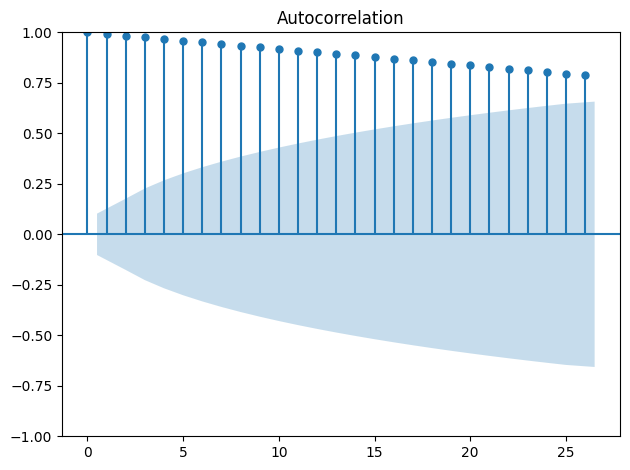

In [93]:
plot_acf(ts)
plt.tight_layout()
plt.show()

## Paso 3: Entrena un ARIMA

**Utilizamos los datos de entrenamiento** para encontrar la mejor parametrización de nuestro modelo ARIMA.   
Para poder utilizar los datos de entrenamiento tenemos que hacer el split. El train tendrá de todo menos los últimos 14 puntos (pasado) y el test de últimos 14 puntos (futuro).

Un modelo  consta de tres hiperparámetros:   
p: El orden del componente autorregresivo (AR).   
d: El grado de diferenciación necesario para hacer la serie de tiempo estacionaria.   
q: El orden del componente de media móvil (MA).   

In [94]:
test = ts.iloc[-14:]
train = ts.iloc[:-14]

In [95]:
# We train ARIMA model
model = auto_arima(train, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1776.268, Time=1.07 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2020.899, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1896.242, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2127.326, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=1.19 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=1772.831, Time=1.63 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=1774.592, Time=1.62 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=2.21 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=inf, Time=1.50 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=1.12 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=2.15 sec
 ARIMA(3,1,2)(2,0,1)[7] intercept   : AIC=1775.212, Time=1.56 sec
 ARIMA(2,1,3)(2,0,1)[7] intercept   : AIC=1770.790, Time=1.86 sec
 A

 En este caso tendríamos un ARIMA (2,1,3).

In [96]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  352
Model:             SARIMAX(2, 1, 3)x(2, 0, [1], 7)   Log Likelihood                -875.395
Date:                             Mon, 08 Dec 2025   AIC                           1770.790
Time:                                     14:18:40   BIC                           1809.398
Sample:                                 09-03-2022   HQIC                          1786.155
                                      - 08-20-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      9.5657      2.065      4.632      0.000       5.518      13.613
ar.L1         -1.3658      0.213     -6.411      0.000      -1.783      -0.948
ar.L2         -0.7951      0.190     -4.179      0.000      -1.168      -0.422
ma.L1          0.3180      0.239      1.332      0.183      -0.150       0.786
ma.L2         -0.5697      0.176     -3.235      0.001      -0.915      -0.225
ma.L3         -0.7131      0.222     -3.213      0.001      -1.148      -0.278
ar.S.L7       -0.3992      0.261     -1.527      0.127      -0.911       0.113
ar.S.L14       0.2347      0.062      3.766      0.000       0.113       0.357
ma.S.L7        0.5964      0.272      2.191      0.028       0.063       1.130
sigma2         8.5543      0.696     12.287      0.000       7.190       9.919
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.63
Prob(Q):                              0.93   Prob(JB):                         0.73
Heteroskedasticity (H):               0.91   Skew:                             0.08
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Paso 4: Predice con el conjunto de test

In [97]:
forecast = model.predict(n_periods=len(test))
forecast

2023-08-21    965.498014
2023-08-22    968.693508
2023-08-23    971.275291
2023-08-24    974.834691
2023-08-25    975.778166
2023-08-26    978.274536
2023-08-27    980.497349
2023-08-28    983.562123
2023-08-29    986.218309
2023-08-30    988.765865
2023-08-31    991.580414
2023-09-01    994.607800
2023-09-02    996.323488
2023-09-03    998.848774
Freq: D, dtype: float64

In [98]:
forecast = pd.Series(forecast, index=test.index)

In [99]:
# We compare
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mae, rmse

(2.1510853046774026, np.float64(2.557399015876527))

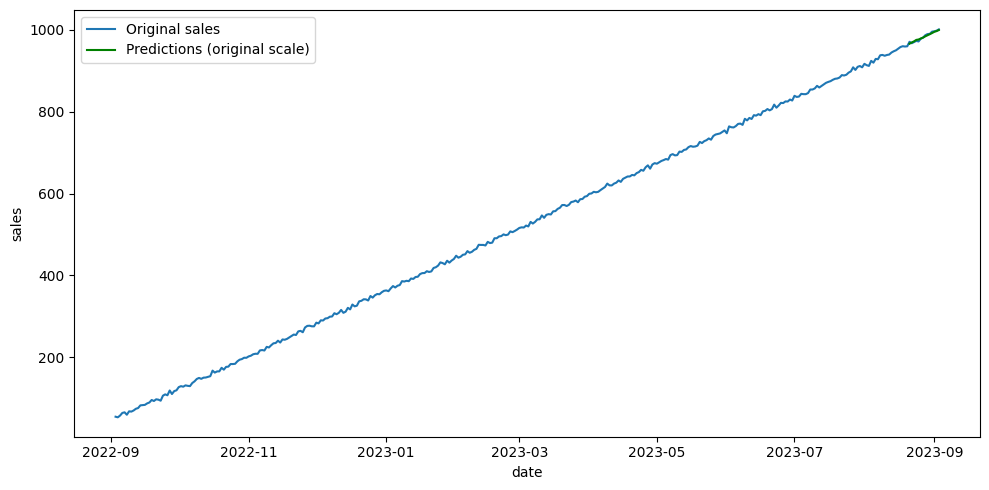

In [100]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts, label='Original sales')
sns.lineplot(data=forecast, label='Predictions (original scale)', c='green')

plt.tight_layout()
plt.show()

> #### Conclusiones:
>
> El MAE de aproximadamente 2 unidades indica que, en promedio, la predicción se desvía en 2 unidades respecto a los valores reales.   
> El RMSE, ligeramente mayor (≈2.46), refleja que los errores más grandes tienen un efecto mayor, pero sigue siendo bajo.   
> Esto sugiere que el modelo captura correctamente la tendencia y la estacionalidad de la serie temporal para este horizonte de predicción.

## Paso 5: Guarda el modelo

In [101]:
with open('/workspaces/inetke-machine-learning/models/time-series-forecasting-sales.pkl', 'wb') as file:
    pickle.dump(model, file)